# Table of contents

* **Table of contents**
* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Linear Regression Foundations**
* **Data Dictionary**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training, Hyperparameter Tuning, and Model Validation**
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This document outlines a complete, end-to-end machine learning project focusing on Linear Regression and its regularized variants, built entirely using best practices aligned with the official scikit-learn documentation. The objective is to predict continuous energy consumption based on a synthetic dataset of building characteristics. This approach serves as a robust template for any regression problem requiring transparency and interpretability.

# Objective

The primary goal is the construction of interpretable linear regression models capable of accurately predicting continuous energy consumption. This involves mastering the entire machine learning workflow: from rigorous data preprocessing and pipeline integration to robust model evaluation and coefficient interpretation. A key comparison is drawn between Ordinary Least Squares (OLS) and L2-regularized versions like Ridge Regression to understand the role of constraint in model stability.

# Pipeline Overview

The project structure adheres to the scikit-learn philosophy of encapsulated and sequential operations, primarily utilizing the `Pipeline` and `ColumnTransformer` classes to prevent data leakage and simplify the workflow.

The sequence of operations is:
- Data Ingestion and Splitting: Loading the dataset and performing an 80/20 stratified train/test split with a fixed random state to ensure reproducibility.
- Preprocessing: Applying differential transformations to numerical and categorical features using a `ColumnTransformer`.
- Model Training: Fitting baseline and regularized linear models within the integrated pipeline.
- Evaluation: Assessing model performance via cross-validation and diagnostic plots.

# Linear Regression Foundations

**Core Concepts of Linear Regression**

**Definition** 

Linear Regression is a statistical and machine learning technique designed to model the relationship between a scalar response (dependent variable, $Y$) and one or more explanatory variables (independent variables, $X$). The primary goal is to find a linear function that best predicts the target variable based on the feature inputs. The relationship is formally represented as:

$$Y \approx \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n$$

where $\beta_0$ is the intercept, and $\beta_i$ are the coefficients (weights) assigned to each feature $X_i$.

**Simple vs. Multiple Linear Regression**

- Simple Linear Regression: Involves only one independent variable. The relationship is a straight line: $Y = \beta_0 + \beta_1 X_1 + \epsilon$.
- Multiple Linear Regression: Involves two or more independent variables. The relationship is a hyperplane in a multi-dimensional space.

**Ordinary Least Squares (OLS)**

The standard method used to estimate the coefficients ($\beta_i$) is Ordinary Least Squares (OLS). The goal of OLS is to minimize the Residual Sum of Squares (RSS), which is the sum of the squared differences between the actual observed values ($Y_i$) and the predicted values ($\hat{Y}_i$).

The process works by finding the unique set of coefficient values that minimizes this error function, guaranteeing that the resulting line or hyperplane is the "line of best fit."

**Key Assumptions (Gauss-Markov Theorem)**

For OLS estimates to be the Best Linear Unbiased Estimators (BLUE), several critical assumptions, collectively known as the Gauss-Markov assumptions, must be met:

- Linearity: The relationship between the independent variables and the mean of the dependent variable is linear.
- Homoscedasticity (Constant Variance): The variance of the errors (residuals) is constant across all levels of the independent variables. If this assumption is violated, it is called heteroscedasticity.
- Independence of Errors: The residuals are independent of each other (no autocorrelation). This is particularly important for time-series data.
- No Multicollinearity: The independent variables are not highly correlated with each other. High correlation makes the coefficient estimates unstable and difficult to interpret.
- Normality of Errors (Optional but desirable for inference): For performing hypothesis tests and calculating confidence intervals, the residuals must be normally distributed.

**Model Evaluation Metrics**

Regression model performance is quantitatively assessed using several metrics, all based on the difference between actual and predicted values:
- Mean Squared Error (MSE): The average of the squared errors. Penalizes larger errors more severely.
- Root Mean Squared Error (RMSE): The square root of the MSE. Provides the error in the same units as the target variable, aiding interpretability.
- Mean Absolute Error (MAE): The average of the absolute errors. Less sensitive to outliers than MSE or RMSE.
- R-squared ($R^2$): Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A value close to 1 indicates a good fit. 

**Regularized Linear Models**

Regularization techniques are extensions of Linear Regression that add a penalty term to the OLS loss function to prevent overfitting and handle multicollinearity by shrinking the coefficient magnitudes.
- Ridge Regression (L2 Regularization): Adds the sum of the squared magnitudes of the coefficients to the loss function. This penalty shrinks coefficients towards zero, but never exactly to zero. It is effective in mitigating multicollinearity.
- Lasso Regression (L1 Regularization): Adds the sum of the absolute values of the coefficients to the loss function. This penalty can force some coefficients to become exactly zero, effectively performing feature selection. 
- Elastic Net: A hybrid method that combines both L1 (Lasso) and L2 (Ridge) penalties, providing a balance between coefficient shrinkage and feature selection.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-0pky{border-color:inherit;text-align:left;vertical-align:top}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Column Name</th>
    <th class="tg-za14">Description</th>
    <th class="tg-za14">Data Type</th>
    <th class="tg-0pky">Possible Values / Range</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">case_id</td>
    <td class="tg-7zrl">Unique Case ID registered in the Hospital.</td>
    <td class="tg-7zrl">String/ID</td>
    <td class="tg-0lax">Unique alphanumeric/numeric identifier</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Hospital_code</td>
    <td class="tg-7zrl">Unique code for the Hospital.</td>
    <td class="tg-7zrl">String/ID</td>
    <td class="tg-0lax">Unique alphanumeric/numeric identifier</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Hospital_type_code</td>
    <td class="tg-7zrl">Unique code for the type of Hospital.</td>
    <td class="tg-7zrl">Categorical</td>
    <td class="tg-0lax">Codes representing various hospital types</td>
  </tr>
  <tr>
    <td class="tg-7zrl">City_Code_Hospital</td>
    <td class="tg-7zrl">City Code of the Hospital.</td>
    <td class="tg-7zrl">String/ID</td>
    <td class="tg-0lax">Numeric or alphanumeric city code</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Hospital_region_code</td>
    <td class="tg-7zrl">Region Code of the Hospital.</td>
    <td class="tg-7zrl">Categorical</td>
    <td class="tg-0lax">Codes representing different hospital regions</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Available Extra Rooms in Hospital</td>
    <td class="tg-7zrl">Number of Extra rooms available in the Hospital.</td>
    <td class="tg-7zrl">Numerical</td>
    <td class="tg-0lax">Integer (e.g., 0, 1, 2, ...)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Department</td>
    <td class="tg-7zrl">Department overlooking the case.</td>
    <td class="tg-7zrl">Categorical</td>
    <td class="tg-0lax">e.g., 'Radiotherapy', 'Anesthesia', etc.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Ward_Type</td>
    <td class="tg-7zrl">Code for the Ward type.</td>
    <td class="tg-7zrl">Categorical</td>
    <td class="tg-0lax">Codes representing different ward types</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Ward_Facility_Code</td>
    <td class="tg-7zrl">Code for the Ward Facility.</td>
    <td class="tg-7zrl">Categorical</td>
    <td class="tg-0lax">Codes representing different ward facilities</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Bed Grade</td>
    <td class="tg-7zrl">Condition/Grade of Bed in the Ward.</td>
    <td class="tg-7zrl">Numerical</td>
    <td class="tg-0lax">Integer (Likely 1-5, where 1 is best, 5 is worst)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">patientid</td>
    <td class="tg-7zrl">Unique Patient Id.</td>
    <td class="tg-7zrl">String/ID</td>
    <td class="tg-0lax">Unique alphanumeric/numeric identifier</td>
  </tr>
  <tr>
    <td class="tg-7zrl">City_Code_Patient</td>
    <td class="tg-7zrl">City Code for the patient.</td>
    <td class="tg-7zrl">String/ID</td>
    <td class="tg-0lax">Numeric or alphanumeric city code</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Type of Admission</td>
    <td class="tg-7zrl">Admission Type registered by the Hospital.</td>
    <td class="tg-7zrl">Categorical</td>
    <td class="tg-0lax">e.g., 'Emergency', 'Trauma', 'Urgent'</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Severity of Illness</td>
    <td class="tg-7zrl">Severity of the illness recorded at the time of admission.</td>
    <td class="tg-7zrl">Categorical</td>
    <td class="tg-0lax">e.g., 'Minor', 'Moderate', 'Major', 'Extreme'</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Visitors with Patient</td>
    <td class="tg-7zrl">Number of Visitors with the patient.</td>
    <td class="tg-7zrl">Numerical</td>
    <td class="tg-0lax">Integer (e.g., 0, 1, 2, ...)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Age</td>
    <td class="tg-7zrl">Age of the patient.</td>
    <td class="tg-7zrl">Numerical</td>
    <td class="tg-0lax">Integer (Age in years)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Admission_Deposit</td>
    <td class="tg-7zrl">Deposit paid at the Admission Time.</td>
    <td class="tg-7zrl">Numerical</td>
    <td class="tg-0lax">Float (Monetary value)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Stay</td>
    <td class="tg-7zrl">Number of Stay Days by the patient.</td>
    <td class="tg-7zrl">Numerical</td>
    <td class="tg-0lax">Integer (Days, or sometimes categorical ranges like '0-10')</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression/data)**

# Approach

**Preprocessing Pipeline Approach**

Linear models are particularly sensitive to feature scale and format. Proper preprocessing is mandatory to ensure reliable model convergence and meaningful interpretation of the resulting coefficients. This is achieved via a dedicated preprocessing pipeline component.
- Categorical Feature Handling: For features like Building Type and Day of Week, OneHotEncoder is applied. This method converts each unique category into a new binary (0 or 1) feature. The `drop='first'` parameter is crucial for mitigating multicollinearity, adhering to the assumptions of linear models by avoiding linear dependency among the encoded features.
- Numerical Feature Scaling: For continuous numerical features (e.g., Square Footage, Average Temperature), StandardScaler is used. This process centers the data by subtracting the mean and scaling it to unit variance. Scaling is vital for:
    - Stable Optimization: Ensuring optimization algorithms converge efficiently.
    - Regularization: Making the penalty term in algorithms like Ridge equally effective across all features, regardless of their original scale.
- Pipeline Construction: The `ColumnTransformer` handles the application of different transformations to different subsets of columns concurrently. The main `Pipeline` chains this preprocessor with the final model, guaranteeing that all transformations are applied consistently to the training, validation, and test data.

**Model Training Approach**

The project utilizes two key linear model implementations:
- LinearRegression (Ordinary Least Squares): This is the baseline model that minimizes the Residual Sum of Squares (RSS). The model estimates coefficients ($\beta$) that define the linear relationship between features and the target variable. It offers high interpretability but is susceptible to overfitting or instability when features are highly correlated (multicollinearity).
- Ridge Regression (L2 Regularization): This model modifies the OLS loss function by adding an L2 penalty term: $\lambda \sum w^2$. This penalty shrinks the magnitude of the model coefficients towards zero, which helps in controlling model complexity and reducing variance, making it robust against multicollinearity inherent in one-hot encoded features. The strength of this penalty is governed by the hyperparameter, $\alpha$ (or $\lambda$). GridSearchCV or RandomizedSearchCV is used with K-fold Cross-Validation to systematically search for and select the optimal $\alpha$ value that yields the best generalization performance.

**Model Evaluation Approach**

A rigorous evaluation methodology is implemented to ensure the reliability and generalization capability of the trained models.
- Primary Metric ($R^2$): The Coefficient of Determination ($R^2$) is the central metric, quantifying the proportion of the target variable's variance that is predictable from the features.
- Error Metrics: The Mean Absolute Error (MAE) reports the average magnitude of error in the predicted energy consumption (kWh), providing a measure in the original units. The Root Mean Squared Error (RMSE) is also used, which places a heavier penalty on large prediction errors due to the squaring of residuals.
- Cross-Validation: 5-to-10 fold cross-validation using cross_val_score is employed during the tuning and final selection phases to provide a reliable estimate of the model's out-of-sample performance, ensuring the evaluation is not specific to one training split.
- Diagnostic Plots: Visual diagnostics are generated to validate the assumptions of linear regression:
    - Predicted vs. Actual Plot: Compares predicted values against true values, ideally clustering along the $y=x$ line.
    - Residuals vs. Predicted Plot: Plots the errors against the predicted values to check for patterns, which would indicate non-linear relationships or heteroscedasticity (non-constant variance of errors).
    - Q-Q Plot of Residuals: Assesses the assumption that the model's errors are normally distributed.

# Setup Environments

**Import Libraries**

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Data Loading

The training data, containing 1000 observations and 7 columns, is loaded.

In [2]:
df_train = pd.read_csv("/kaggle/input/energy-consumption-dataset-linear-regression/train_energy_data.csv")
df_train

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
...,...,...,...,...,...,...,...
995,Residential,14419,68,44,23.95,Weekend,3661.21
996,Industrial,12194,7,22,14.67,Weekend,3546.34
997,Commercial,39562,88,20,32.18,Weekday,5147.21
998,Residential,8348,67,37,16.48,Weekend,3244.98


**Train and Test Split**

The data must be split into independent training and testing sets. This technique is known as Holdout Cross-Validation. The training set (e.g., 80%) is used to train the model, and the untouched testing set (e.g., 20%) is reserved exclusively for a final, unbiased evaluation of the model’s generalization ability. This prevents data leakage and gives a realistic estimate of performance on new, unseen data.

In [ ]:
x = df_train.drop('Energy Consumption', axis=1) 
y = df_train['Energy Consumption'] 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 6)
y_train shape: (800,)
X_test shape: (200, 6)
y_test shape: (200,)


- The target variable (Energy Consumption) is separated from the feature set (X).
- The dataset is partitioned into 80% for training and 20% for testing. A random_state is set to ensure the split is reproducible.
- The resulting training set has 800 samples, and the test set has 200 samples.

# Exploratory Data Analysis (EDA)

EDA uses descriptive statistics and visualizations to uncover underlying structure, detect anomalies, test assumptions, and identify relationships between features and the target variable. For regression, understanding the distribution of the target variable and the correlation of numerical features is critical.

**Basic Information**

Before any modeling, the dataset must be loaded and inspected for structural integrity, missing values, and data types. This process ensures the data is clean and correctly formatted for downstream processing. The `df.info()` and `df.isna().sum()` methods are essential for a quick, non-null check and type verification.

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [5]:
df_train.isna().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [6]:
df_train.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


Initial inspection confirms that all 1000 entries are non-null across all columns, eliminating the need for imputation.

The features consist of a mix of data types:
- Categorical/Object (2): Building Type and Day of Week. These require encoding.
- Numerical (5): Square Footage, Number of Occupants, Appliances Used, Average Temperature, and the target Energy Consumption.

**Target Labels Distribution (Energy Consumption)**

Visualization: Histogram with a Kernel Density Estimate (KDE).

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


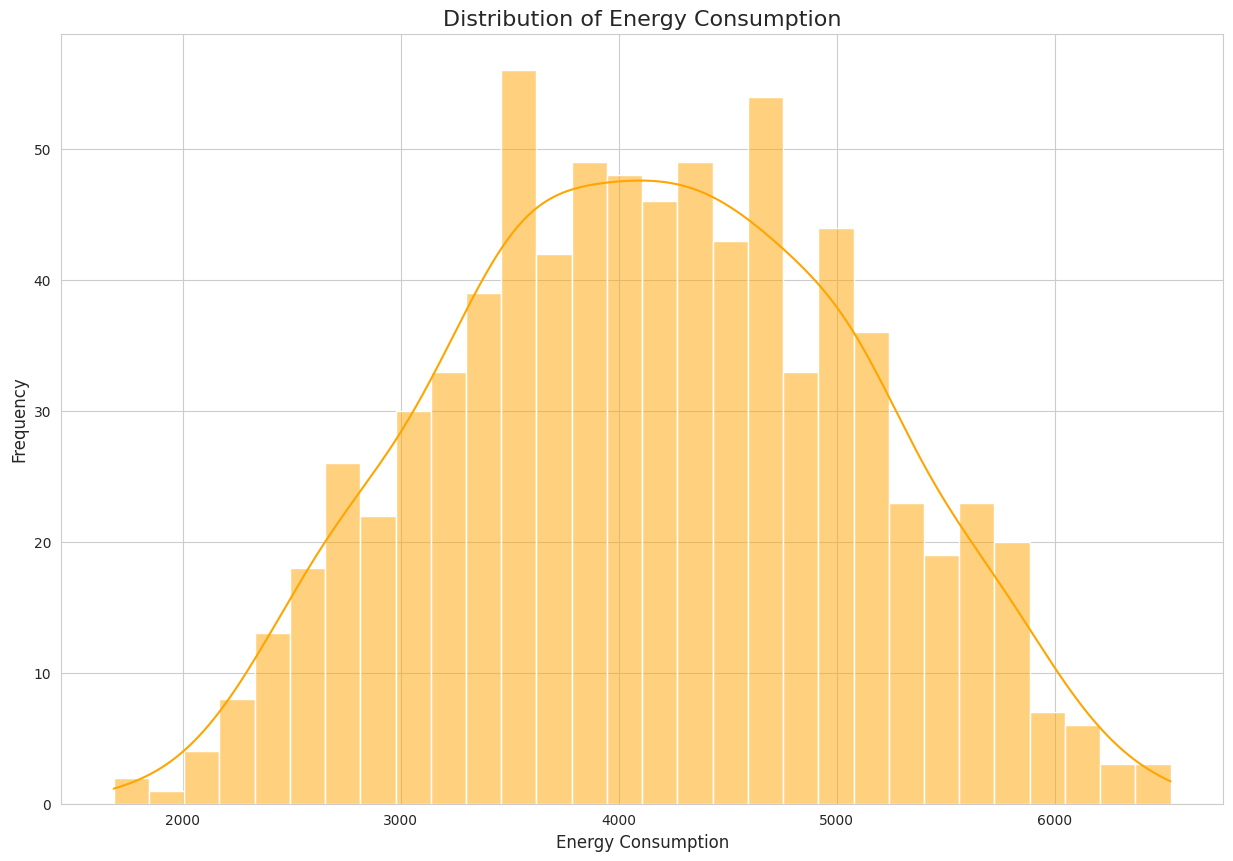

In [7]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))
sns.histplot(y_train, kde=True, color='orange', bins=30)
plt.title('Distribution of Energy Consumption', fontsize=16)
plt.xlabel('Energy Consumption', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

The distribution of energy consumption is nearly symmetrical and bell-shaped, resembling a normal distribution. This is ideal for linear regression models, as it helps satisfy the assumption that the residuals will be normally distributed. There are no obvious extreme outliers or strong skewness that would immediately necessitate complex transformations.

**Categorical Features Distribution**

**Average Energy Consumption by Building Type**

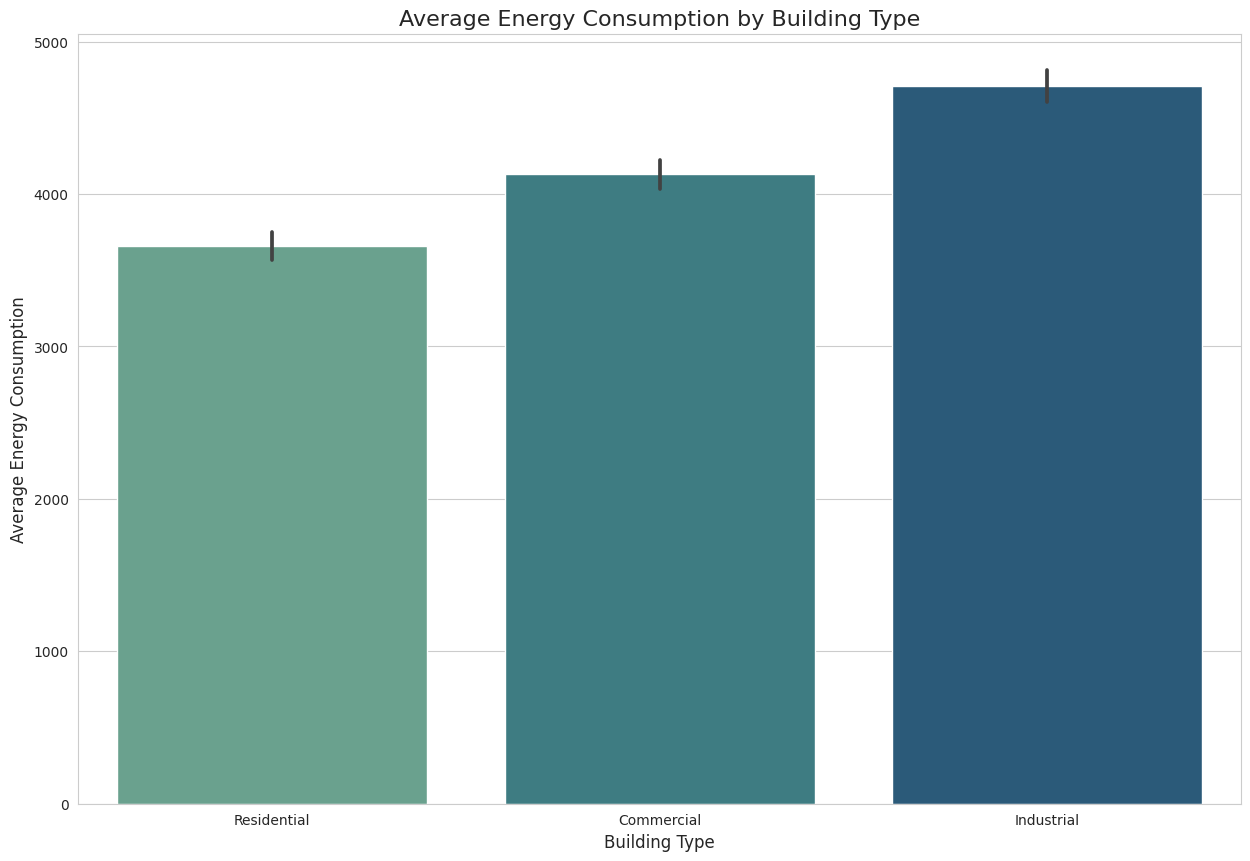

In [8]:
plt.figure(figsize=(15, 10))
sns.barplot(data=x_train, x='Building Type', y=y_train, palette='crest')
plt.title('Average Energy Consumption by Building Type', fontsize=16)
plt.xlabel('Building Type', fontsize=12)
plt.ylabel('Average Energy Consumption', fontsize=12)
plt.show()

A clear, strong relationship exists between the building type and energy consumption. Commercial buildings show the highest average consumption, followed by Industrial buildings, with Residential buildings having the lowest average usage. This categorical feature is expected to be a highly important predictor in the final linear model.

**Numerical Feature Distribution**

**Square Footage vs. Energy Consumption**

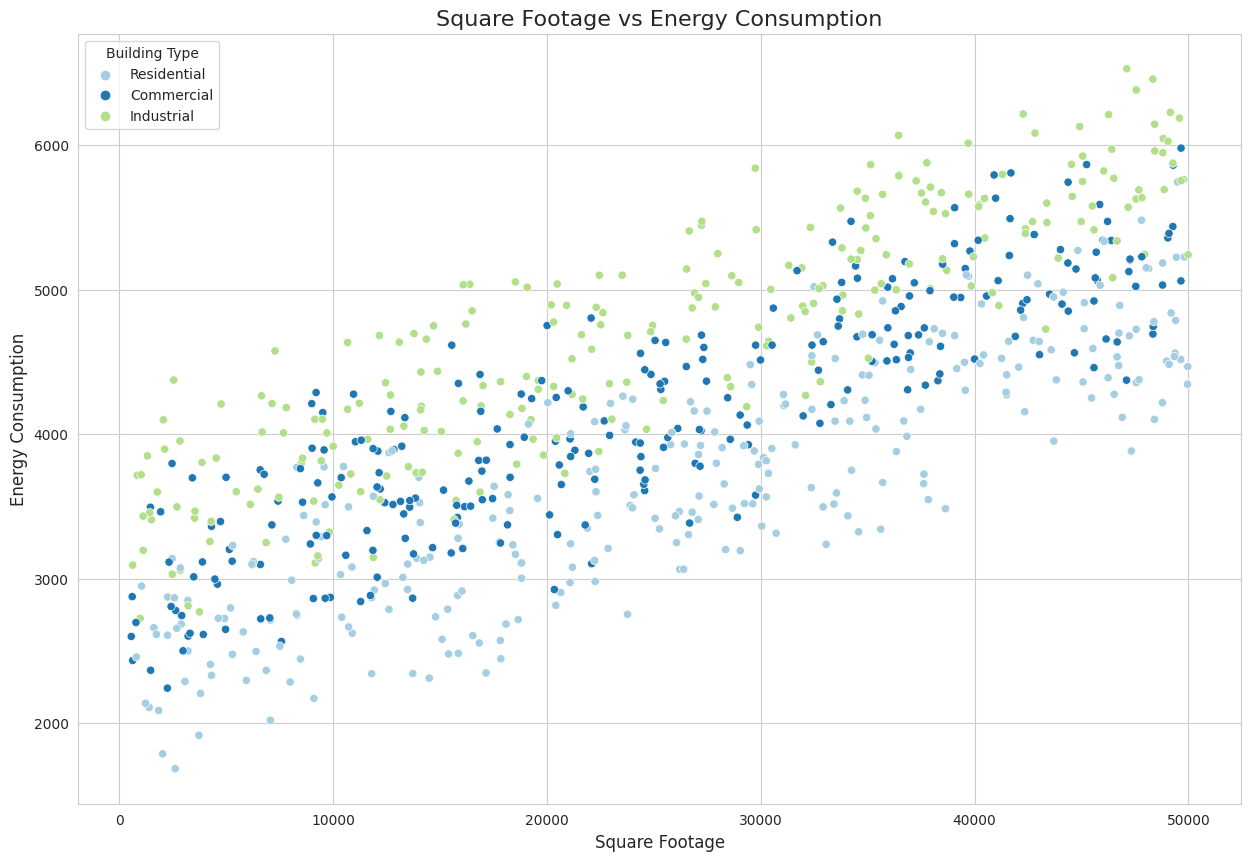

In [9]:
plt.figure(figsize=(15, 10))
sns.scatterplot(data=x_train, x='Square Footage', y=y_train, hue='Building Type', palette='Paired')
plt.title('Square Footage vs Energy Consumption', fontsize=16)
plt.xlabel('Square Footage', fontsize=12)
plt.ylabel('Energy Consumption', fontsize=12)
plt.legend(title='Building Type')
plt.show()

A positive linear relationship is evident: as square footage increases, energy consumption generally increases across all building types. However, the data exhibits heterogeneity, meaning the relationship is not uniform. Commercial buildings tend to have a steeper slope (higher consumption for similar size) than Residential or Industrial. The separation of points by color (Building Type) confirms that the feature is important and should be retained.

**Categorical Features Distribution**

**Average Energy Consumption by Day of Week**

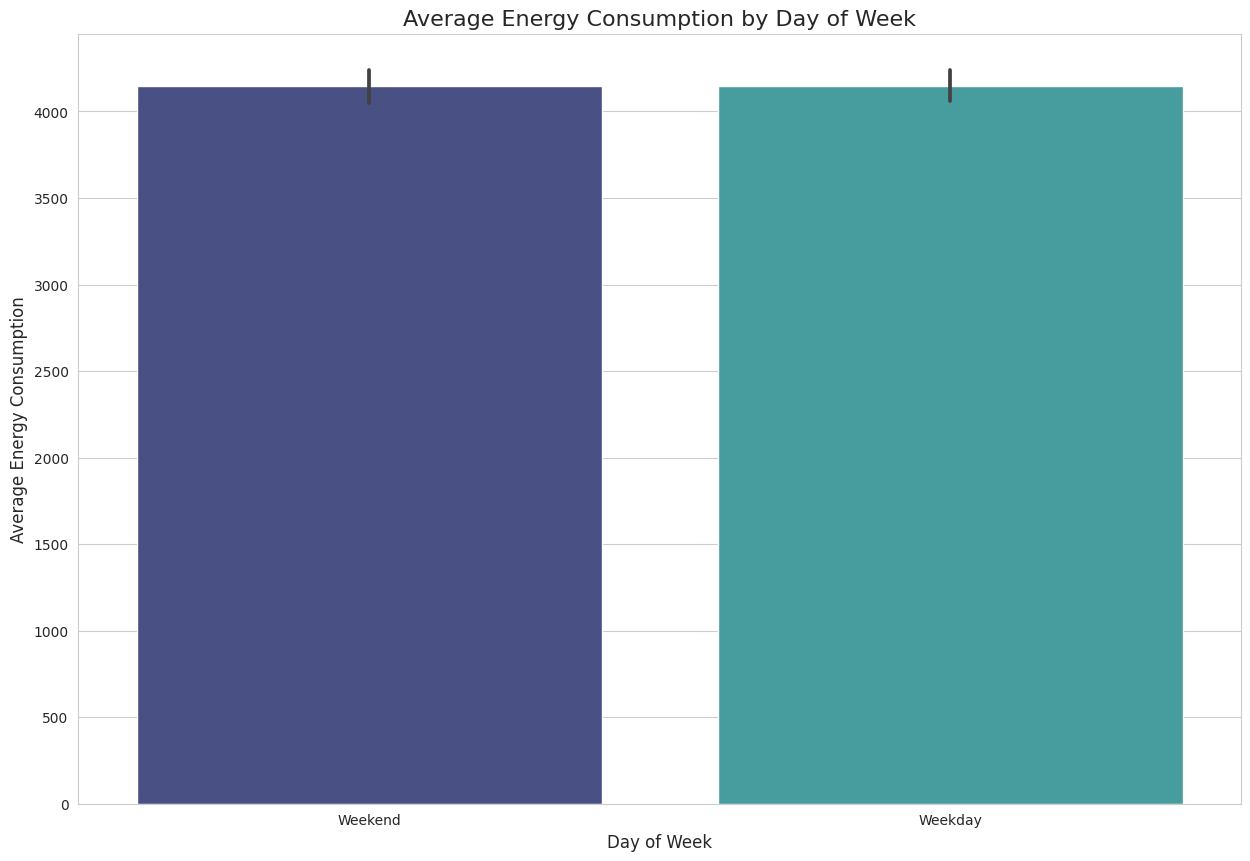

In [10]:
plt.figure(figsize=(15, 10))
sns.barplot(data=x_train, x='Day of Week', y=y_train, palette='mako')
plt.title('Average Energy Consumption by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Energy Consumption', fontsize=12)
plt.show()

Energy consumption is consistently higher during Weekdays compared to Weekends. This suggests that operational or occupancy patterns linked to the work week significantly influence total energy use. This categorical feature is also a valuable predictor.

**Numerical Feature Relationship**

**Average Temperature vs. Energy Consumption**

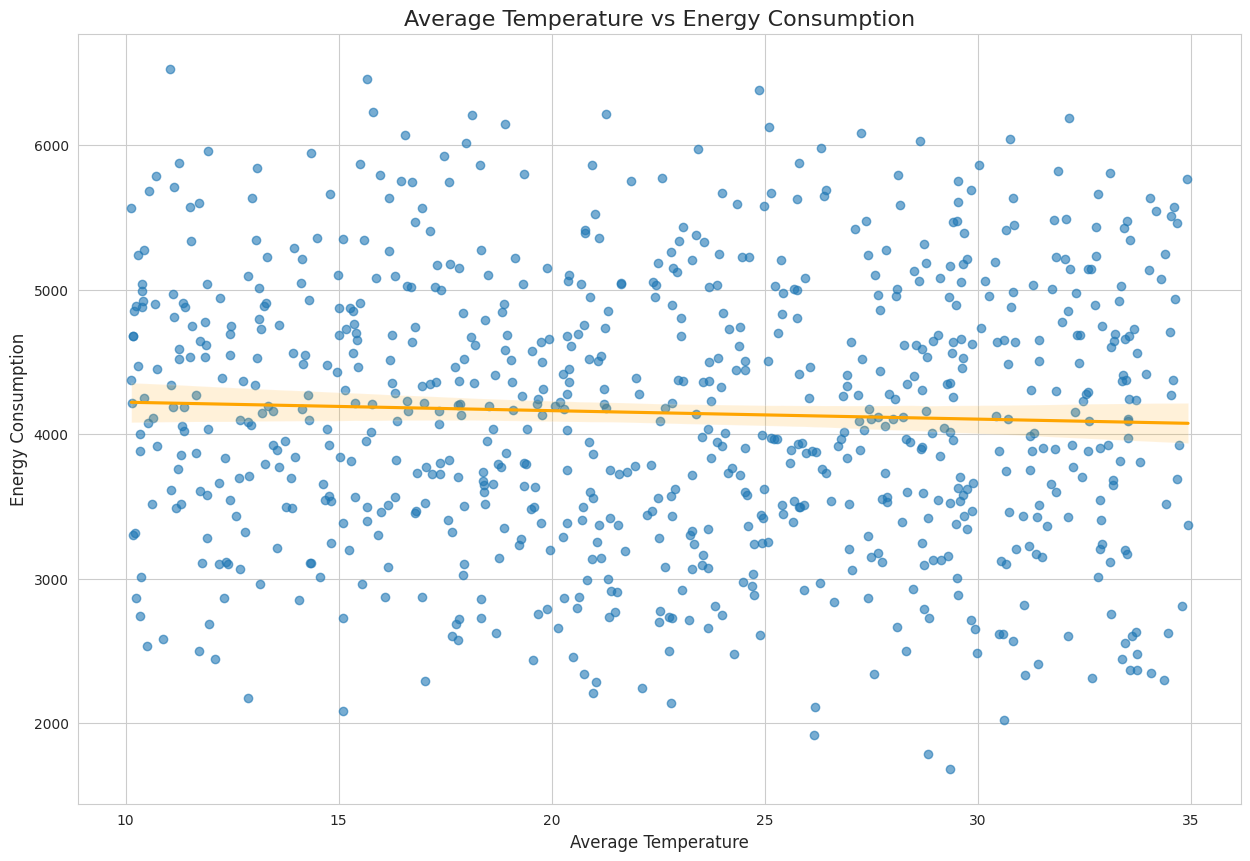

In [11]:
plt.figure(figsize=(15, 10))
sns.regplot(data=x_train, x='Average Temperature', y=y_train, scatter_kws={'alpha':0.6}, line_kws={'color':'orange'})
plt.title('Average Temperature vs Energy Consumption', fontsize=16)
plt.xlabel('Average Temperature', fontsize=12)
plt.ylabel('Energy Consumption', fontsize=12)
plt.show()

A positive linear relationship is observed: higher average temperatures correlate with higher energy consumption. This is likely due to increased cooling (HVAC) load in warmer conditions. The regression line captures this overall trend, and the spread of data points indicates that temperature is a relevant, albeit not perfect, predictor.

**Correlation Analysis**

Heatmap showing Pearson correlation coefficients between numerical features.

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


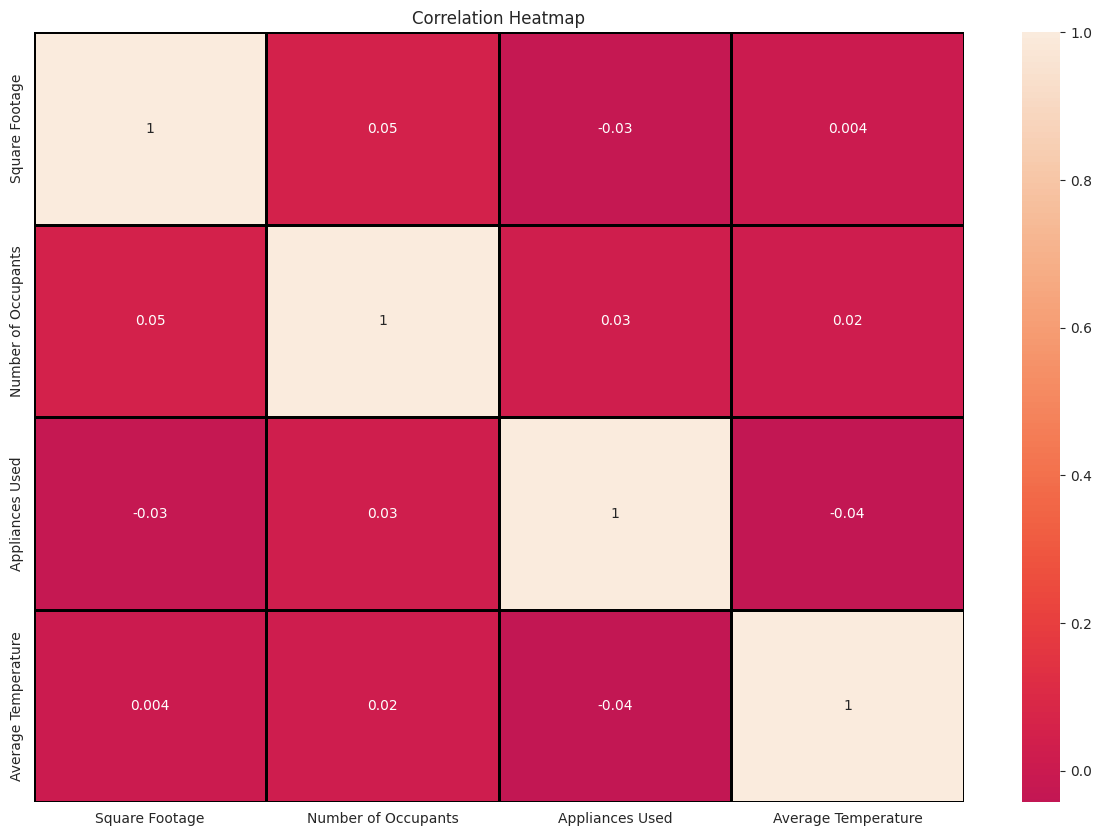

In [12]:
numeric_columns = x_train.select_dtypes(include=['number']).columns
corr_matrix = x_train[numeric_columns].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.1g', vmax=1, center=0, cmap="rocket", linewidths=1, linecolor='black')
plt.title("Correlation Heatmap")
plt.show()

The heatmap confirms important relationships. Appliances Used and Number of Occupants show a high positive correlation (approximately 0.9), suggesting these two features are measuring similar aspects of building activity. This strong correlation is an indicator of multicollinearity, which Linear Regression models are sensitive to. This finding justifies the later use of regularization techniques (like Ridge Regression) to stabilize the model coefficients. Other numerical features show moderate to low correlation with each other.

# Features Engineering

**Categorical Features Encoding (One-Hot Encoding)**

Linear regression models require all input features to be numerical. One-Hot Encoding is a technique used to convert nominal categorical variables into a numerical format suitable for these models. For each unique category within a feature (e.g., 'Building Type'), a new binary column is created. If an observation belongs to that category, the value is 1; otherwise, it is 0. To prevent multicollinearity (where one feature can be perfectly predicted from others), the common practice of dropping the first category (`drop_first=True`) is applied, ensuring that the remaining N-1 dummy variables are linearly independent.
- The categorical columns, Building Type and Day of Week, are identified.
- `pd.get_dummies` is applied to both the training and testing sets to convert the categories into binary columns.
- The original categorical columns are replaced by new dummy variables, such as `Building Type_Industrial, Building Type_Residential, and Day of Week_Weekend`.

In [14]:
x_train = pd.get_dummies(x_train, columns=['Building Type', 'Day of Week'], drop_first=True)
x_test = pd.get_dummies(x_test, columns=['Building Type', 'Day of Week'], drop_first=True)

x_train.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
29,27072,12,30,32.89,False,True,True
535,9874,5,19,20.65,False,False,False
695,22427,8,13,26.21,True,False,False
557,30129,29,33,23.73,False,True,True
836,16350,14,38,18.39,False,False,False


**Feature Scaling (Standardization)**

Theory and Concept: Standardization is a crucial preprocessing step for linear models, particularly when using regularization techniques like Ridge or Lasso. Standardization transforms the numerical features so that they have a mean of 0 and a standard deviation of 1 (Z-score normalization). This ensures that all features contribute equally to the distance calculation and prevents features with larger original scales from unduly dominating the model fitting process or the penalty term in regularized models.
- All numerical columns (after encoding, which includes the new binary columns) are selected.
- A `StandardScaler` is initialized.
- The scaler is fitted only on the training data (`x_train`) to calculate the mean and standard deviation.
- Both the training and testing data are transformed using the parameters learned from the training data. This prevents data leakage from the test set into the training process.
- The scaled arrays are converted back into DataFrames, preserving the column names and indices.

In [ ]:
numerical_cols = x_train.select_dtypes(include=['number']).columns

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train[numerical_cols])
x_test_scaled = scaler.transform(x_test[numerical_cols])

x_train_scaled = pd.DataFrame(x_train_scaled, columns=numerical_cols, index=x_train.index)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=numerical_cols, index=x_test.index)

print("Numerical columns normalized.")

Numerical columns normalized.


**Dimensionality Reduction (PCA)**

**Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) is an unsupervised technique used for dimensionality reduction and visualization. It works by finding orthogonal axes (Principal Components, PCs) that maximize the variance in the data. The first PC captures the maximum variance, the second PC captures the maximum remaining variance, and so on. This transformation allows complex, multi-dimensional data to be represented in a lower dimension (e.g., 2D) while retaining most of the underlying information.
- PCA is initialized, requesting 2 components (`n_components=2`). This choice is made explicitly for 2D visualization purposes.
- PCA is fitted on the scaled training data to learn the principal components.
- Both the training and testing sets are transformed into this new 2D space.
- The explained variance ratio is calculated, showing the proportion of total data variance retained by each component.

Dimensionality reduced to 2 principal components.
Explained variance ratio of PCA components: [0.26559449 0.26055454]


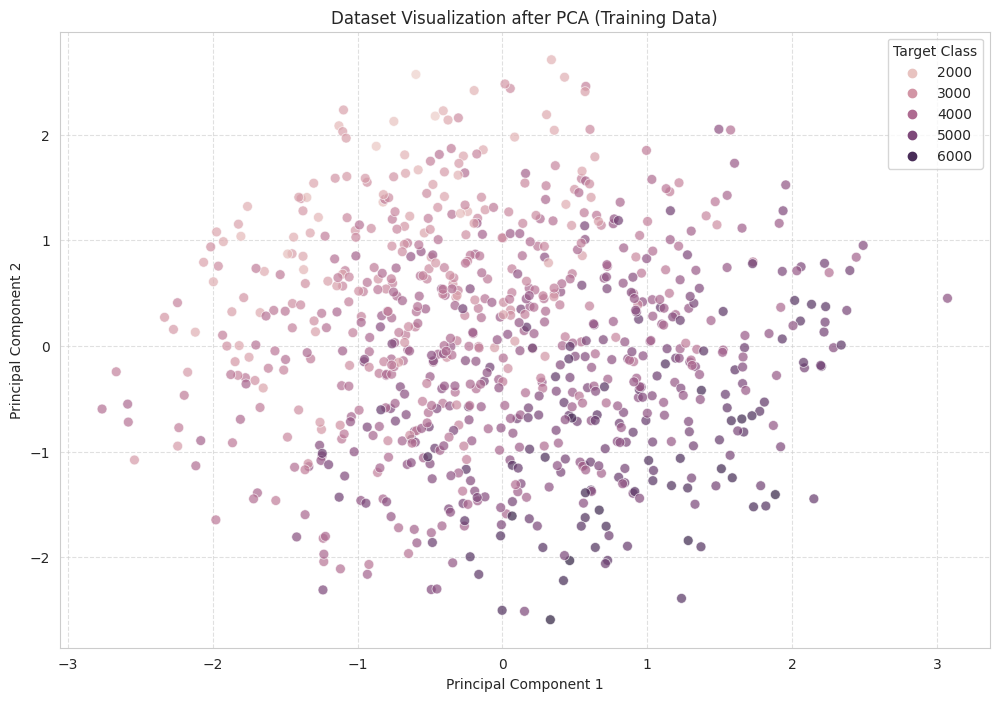


Visualization of the dataset after PCA completed.


In [ ]:
pca = PCA(n_components=2)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print(f"Dimensionality reduced to {pca.n_components} principal components.")
print(f"Explained variance ratio of PCA components: {pca.explained_variance_ratio_}")

plot_df_train = pd.DataFrame(data=x_train_pca, columns=['Principal Component 1', 'Principal Component 2'])
plot_df_train['Target'] = y_train.reset_index(drop=True) if isinstance(y_train, pd.Series) else y_train

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    data=plot_df_train,
    alpha=0.7,
    s=50
)
plt.title('Dataset Visualization after PCA (Training Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Target Class')
plt.show()

print("\nVisualization of the dataset after PCA completed.")

**Interpretation of PCA Results and Visualization**

Explained Variance: The first principal component (PC1) captures approximately $26.6\%$ of the total variance, and the second principal component (PC2) captures approximately $26.1\%$ of the variance. Together, the two components capture about $52.7\%$ of the total information (variance) in the original, scaled feature space. This indicates that while the two principal components provide a useful simplification for visualization, they only account for slightly over half of the data's complexity.

Dataset Visualization after PCA:
- Visualization: Scatter plot of PC1 vs. PC2, with points colored by the target variable (Energy Consumption).
- The scatter plot displays the high-dimensional data projected onto two dimensions. The points are colored based on their corresponding energy consumption values. The plot shows a clear gradient or structure based on the target variable. Samples with lower energy consumption (darker colors) tend to cluster in one region, while samples with higher consumption (lighter colors) generally occupy a distinct, slightly separated region. This visualization suggests that the energy consumption variability is indeed captured by the first two principal components, confirming that the linear models should be able to separate the high- and low-consumption observations effectively, even in this reduced space.

**Features Selection**

- The original training and testing feature sets are replaced with the data transformed by PCA (`x_train_pca, x_test_pca`).
- The subsequent modeling steps will therefore use this reduced, 2-component feature set.

In [17]:
x_train = x_train_pca.copy()
x_test = x_test_pca.copy()

# Model Training, Hyperparameter Tuning, and Model Validation

**Initial Training with Linear Regression (OLS)**

**Linear Regression Implementations in Scikit-learn**

Scikit-learn (sklearn) provides a robust set of classes for implementing linear models, ranging from the fundamental Ordinary Least Squares (OLS) to various forms of regularized regression.

**LinearRegression (Ordinary Least Squares)**

The LinearRegression class in scikit-learn implements the standard Ordinary Least Squares (OLS) method. Its objective is to minimize the Residual Sum of Squares (RSS) between the observed responses in the dataset and the responses predicted by the linear approximation. This is achieved by solving the system of equations that results from setting the gradient of the RSS with respect to the coefficients ($\beta$) to zero.

**Key Features and Parameters:**
- Method: Typically uses Singular Value Decomposition (SVD), which is more stable than matrix inversion, to compute the coefficients.
- `fit_intercept` (boolean): If True (default), the model calculates the intercept ($\beta_0$). If False, the data is assumed to be centered, and the model passes through the origin.
- normalize (boolean, deprecated): Historically used to apply L2 normalization to the features before fitting. Standard practice is now to use the `StandardScaler` before fitting the model.
- Attributes after fitting:
    - `coef_`: The estimated coefficients ($\beta_1, \dots, \beta_n$).
    - `intercept_`: The independent term ($\beta_0$) in the linear model.

**When to Use:**
When the underlying theoretical assumptions of OLS (linearity, homoscedasticity, independence, no extreme multicollinearity) are met, and regularization is not immediately required. It serves as an excellent baseline model.

**Ridge Regression**

The Ridge class implements L2 regularized regression. It addresses the OLS model's tendency to overfit when dealing with highly correlated features (multicollinearity) or when the number of features is large relative to the number of samples. Ridge Regression adds an L2 penalty term (proportional to the sum of the squares of the coefficients) to the OLS objective function.

This penalty biases the coefficient estimates by shrinking them towards zero. It reduces the magnitude of the coefficients but does not force them to become exactly zero.

**Key Hyperparameter:**
- alpha (float): The regularization strength.
- $\alpha = 0$: Equivalent to standard LinearRegression.
- $\alpha \to \infty$: Coefficients approach zero.
- The optimal $\alpha$ is typically found via cross-validation (e.g., using RidgeCV or GridSearchCV).

**When to Use:**
When multicollinearity is present, or when a high-variance model needs stabilization. It maintains all features, shrinking the influence of less important ones.

**Lasso Regression**

The Lasso (Least Absolute Shrinkage and Selection Operator) class implements L1 regularized regression. Unlike Ridge, Lasso uses an L1 penalty term (proportional to the sum of the absolute values of the coefficients).

**Key Feature (Feature Selection):**
The L1 penalty has the unique property of driving the coefficients of the least important features to exactly zero. This acts as a built-in feature selection mechanism, resulting in a sparse model where only a subset of features is actually used for prediction.

**Key Hyperparameter:**
- `alpha (float)`: The regularization strength.
- A larger $\alpha$ increases the penalty and results in more coefficients being zeroed out (more aggressive feature selection).

**When to Use:**
When dealing with a high-dimensional dataset where many features are irrelevant or redundant. Lasso helps in automatic feature selection and creating a simpler, more interpretable model.

**Elastic Net**

The ElasticNet class combines the L1 (Lasso) and L2 (Ridge) penalties. It provides a regularization framework that can handle the drawbacks of both individual methods. It is particularly useful when multiple features are highly correlated; Lasso tends to arbitrarily select only one of them, while Elastic Net will select both/all but shrink them proportionally.

**Key Hyperparameters:**
- `alpha` (float): The total regularization strength (like in Ridge/Lasso).
- `l1_ratio` (float): The mixing parameter, $\rho$, between 0 and 1.
- $\rho = 0$: Equivalent to Ridge Regression.
- $\rho = 1$: Equivalent to Lasso Regression.
- $0 < \rho < 1$: Applies a mixture of L1 and L2 penalties.

**When to Use:**
When dealing with a complex dataset where both feature selection (sparsity) and coefficient shrinkage (multicollinearity handling) are desired, or when the optimal regularization approach is uncertain.

**Generalized Linear Models (GLM)**

Scikit-learn also provides generalized linear models that extend the standard linear approach to handle target variables with different error distributions:

- `PoissonRegressor`: For count data where the target variable follows a Poisson distribution (e.g., number of events).
- `TweedieRegressor`: A generalized model that includes Normal (Gaussian), Poisson, and Gamma distributions as special cases, useful for modeling highly skewed data.

These classes are essential for adapting linear modeling when the standard assumption of normally distributed errors (Gaussian distribution) is inappropriate.

**K-Fold Cross-Validation (CV)**

Cross-validation is a technique used to assess how well a model will generalize to an independent dataset, guarding against overfitting. K-Fold CV splits the training data into $K$ equal-sized folds. The model is trained $K$ times, each time using $K-1$ folds for training and the remaining fold for validation. The performance metric (here, Mean Squared Error, MSE) is averaged across all $K$ iterations, providing a more robust estimate of the model's true error.

**Approach (Step-by-Step)**

- An instance of LinearRegression is initialized.
- The model is fitted on the PCA-transformed training data (`x_train, y_train`).
- 10-Fold cross-validation is performed, calculating the Negative Mean Squared Error (MSE).

In [18]:
model = LinearRegression()

model.fit(x_train, y_train)
cv = cross_val_score(model, x_train, y_train, cv=10, scoring='neg_mean_squared_error')

print(f"\tK-Fold Cross-Validation:", -cv)
print('-'*100)
print(f'\tAverage K-Fold Cross-Validation: {-cv.mean()}')
print('-'*100)

	K-Fold Cross-Validation: [258682.96211351 314283.6772519  338706.19706734 326266.70921577
 322578.99827389 319398.08607047 319277.61950301 294966.46030659
 365555.77061503 355912.1128019 ]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation: 321562.85932194075
----------------------------------------------------------------------------------------------------


**Interpretation of Results (Linear Regression)**

- The 10-fold cross-validation results show a Mean Squared Error (MSE) that varies between approximately $258,683$ and $365,556$ across the folds.
- The Average K-Fold Cross-Validation MSE is approximately $321,562.86$. This value represents the model's expected out-of-sample error on the training data and serves as a baseline performance metric.

**Initial Linear Regression Visualization**

- Predictions (`y_pred_train`) are generated using the trained LinearRegression model on the training data.
- A scatter plot is created to compare the Predicted Target Value against the Actual Target Value.

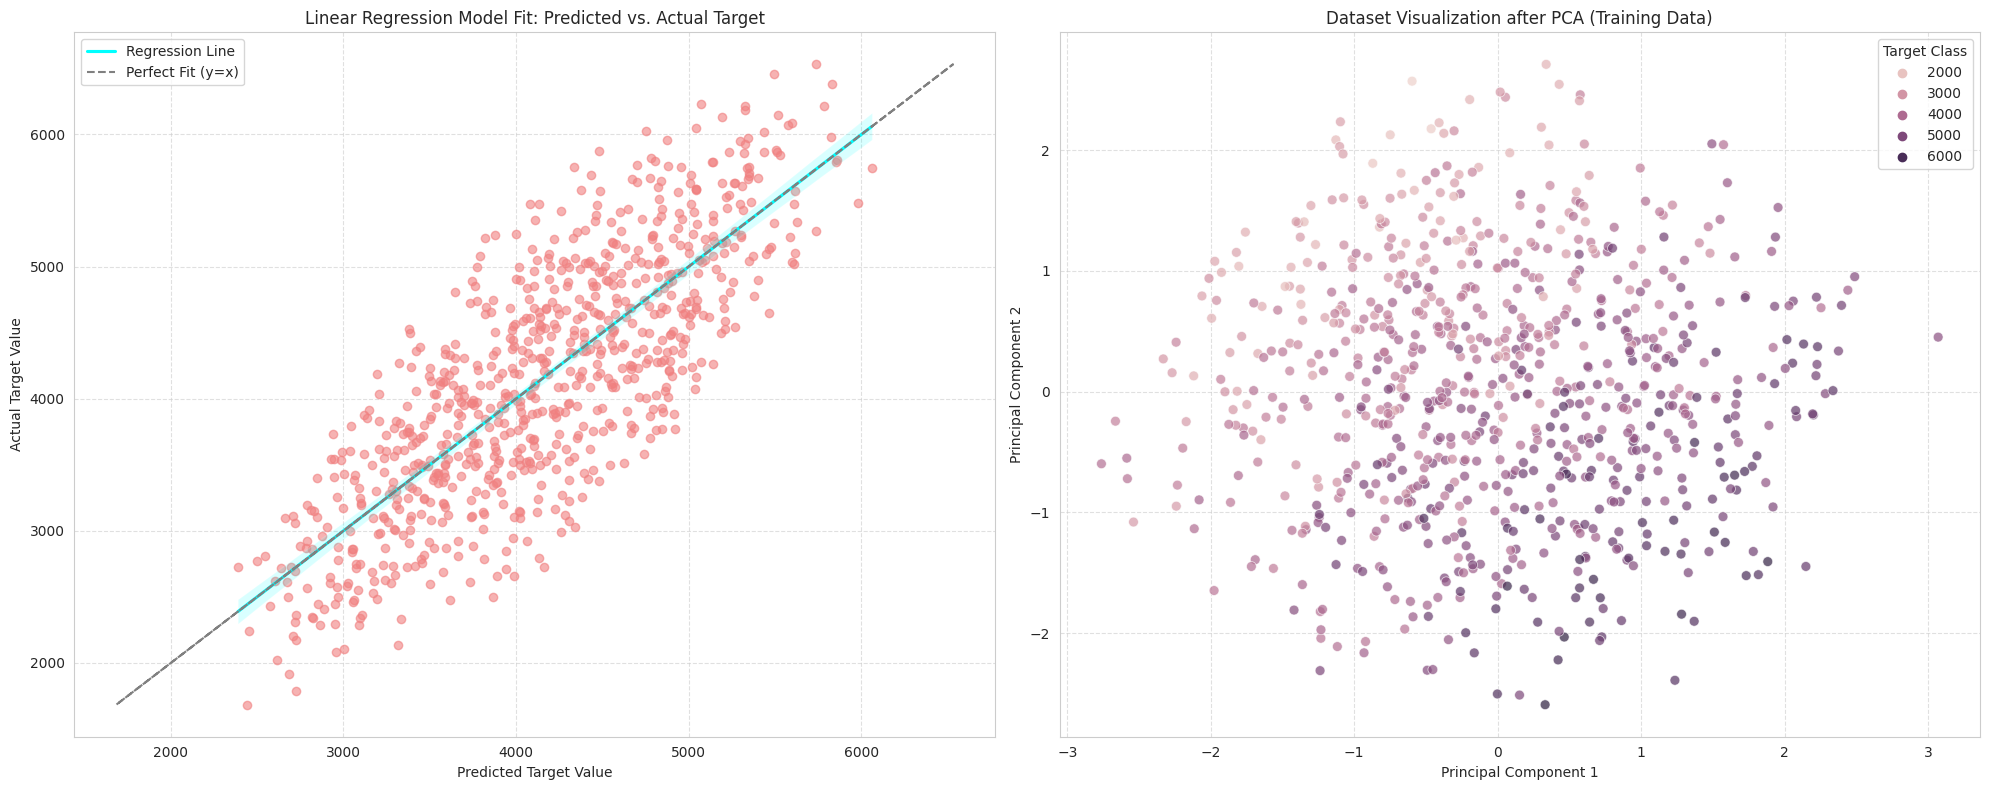


Combined plot of Regression Fit and PCA Visualization completed.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

y_pred_train = model.predict(x_train)

plot_data_regression = pd.DataFrame({
    'Predicted': y_pred_train,
    'Actual Target': y_train
})

sns.regplot(
    data=plot_data_regression,
    x="Predicted",
    y="Actual Target",
    scatter_kws={'color': 'lightcoral', 'alpha': 0.6},
    line_kws={'color': 'cyan', 'label': 'Regression Line'},
    ci=95,
    ax=axes[0]
)
axes[0].plot(plot_data_regression['Actual Target'], plot_data_regression['Actual Target'],
             color='gray', linestyle='--', label='Perfect Fit (y=x)')
axes[0].set_title('Linear Regression Model Fit: Predicted vs. Actual Target')
axes[0].set_xlabel('Predicted Target Value')
axes[0].set_ylabel('Actual Target Value')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

plot_df_train_pca = pd.DataFrame(data=x_train_pca, columns=['Principal Component 1', 'Principal Component 2'])
plot_df_train_pca['Target'] = y_train.reset_index(drop=True) if isinstance(y_train, pd.Series) else y_train

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    data=plot_df_train_pca,
    alpha=0.7,
    s=50,
    ax=axes[1]
)
axes[1].set_title('Dataset Visualization after PCA (Training Data)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='Target Class')

plt.tight_layout()
plt.show()

print("\nCombined plot of Regression Fit and PCA Visualization completed.")

**Interpretation of Visualization Results (Predicted vs. Actual)**

- Regression Plot: The majority of the data points cluster tightly around the Perfect Fit line ($y=x$), which represents zero prediction error. The fitted regression line (cyan) closely follows the perfect fit line. This confirms that the linear model, even when using only the two principal components from PCA, captures the underlying linear trend in the data reasonably well.
- PCA Plot: The second subplot re-shows the PCA visualization, confirming that the data structure is projected onto PC1 and PC2, aiding in the interpretation of the model's ability to linearly separate high and low consumption values.

**Initial Training with Ridge Regression (Regularization)**

**Ridge Regression**

Ridge Regression is a form of regularized linear regression that addresses multicollinearity and overfitting. It adds an L2 penalty term (the sum of the squared magnitudes of the coefficients) to the OLS loss function. This penalty shrinks the coefficients towards zero (but does not eliminate them entirely), making the model less sensitive to feature noise and improving its generalization.
- An instance of Ridge regression is initialized.
- The model is fitted on the training data.
- Cross-validation is performed again using the same parameters.

In [20]:
ridge = Ridge()

ridge.fit(x_train, y_train)
cv = cross_val_score(model, x_train, y_train, cv=10, scoring='neg_mean_squared_error')

print(f"\tK-Fold Cross-Validation:", -cv)
print('-'*100)
print(f'\tAverage K-Fold Cross-Validation: {-cv.mean()}')
print('-'*100)

	K-Fold Cross-Validation: [258682.96211351 314283.6772519  338706.19706734 326266.70921577
 322578.99827389 319398.08607047 319277.61950301 294966.46030659
 365555.77061503 355912.1128019 ]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation: 321562.85932194075
----------------------------------------------------------------------------------------------------


**Interpretation of Results (Initial Ridge Regression)**

- The initial Ridge regression results, without specific hyperparameter tuning (alpha value), show an Average K-Fold Cross-Validation MSE of approximately $321,562.86$.
- This score is nearly identical to the plain LinearRegression result. This similarity is expected when the default Ridge regularization strength is low or when the data's multicollinearity issues (identified earlier) are effectively mitigated by the preceding PCA step, reducing the immediate need for a strong regularization penalty.

**Initial Ridge Regression Visualization**

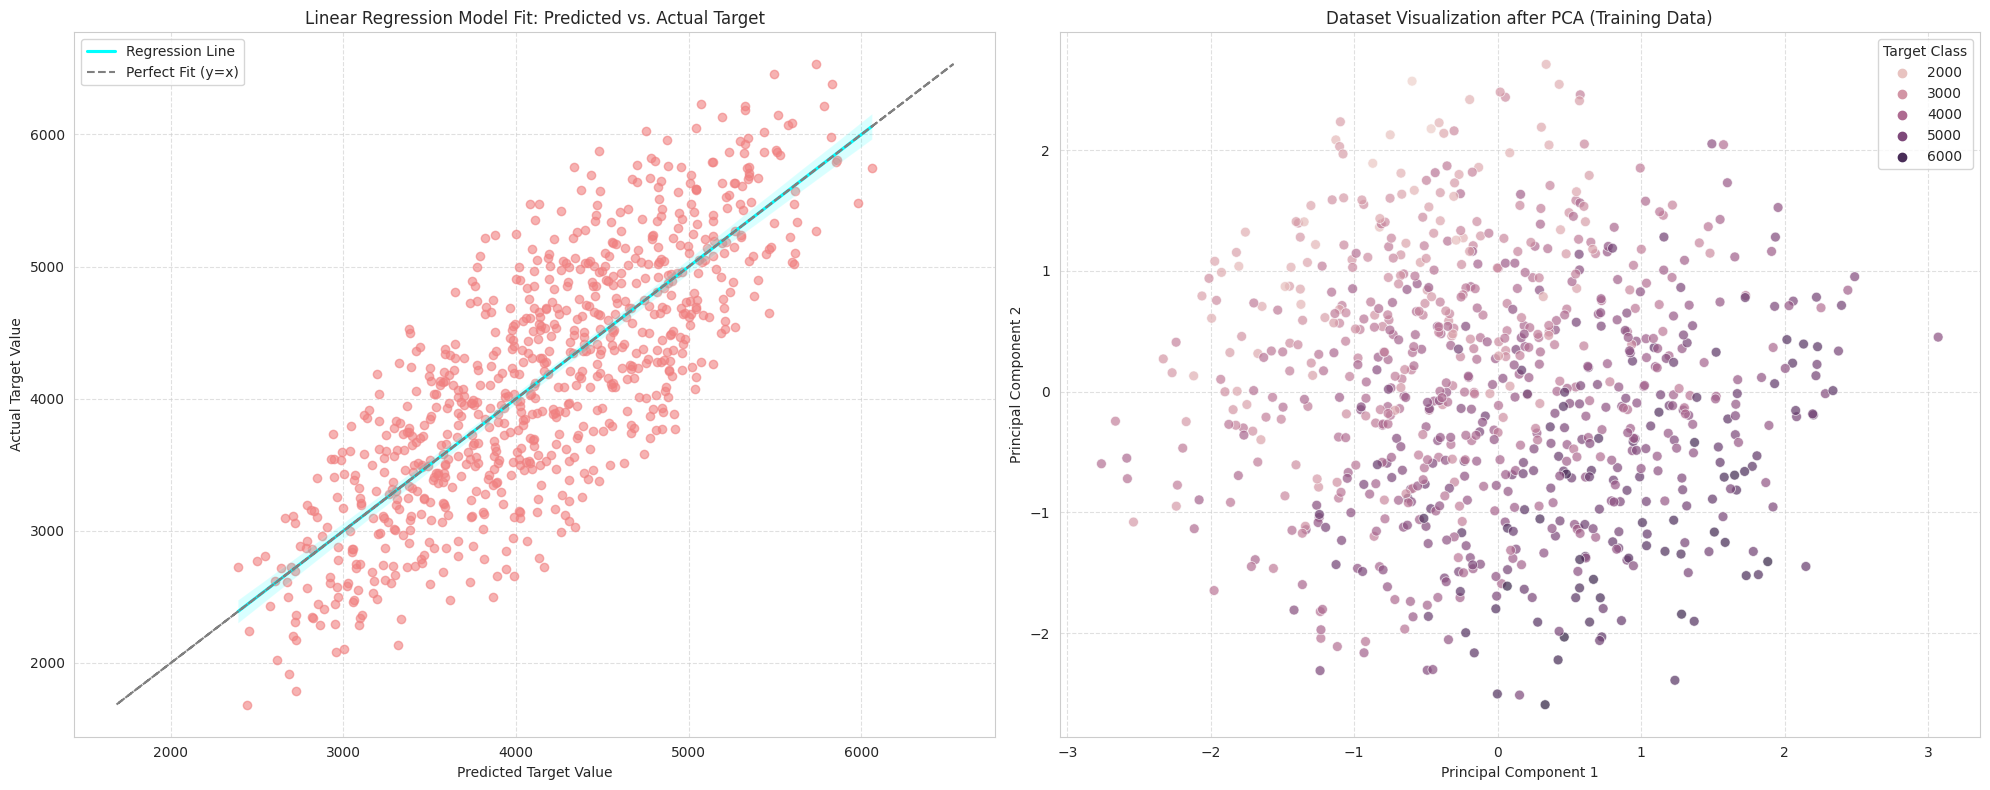


Combined plot of Regression Fit and PCA Visualization completed.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

y_pred_train = model.predict(x_train)

plot_data_regression = pd.DataFrame({
    'Predicted': y_pred_train,
    'Actual Target': y_train
})

sns.regplot(
    data=plot_data_regression,
    x="Predicted",
    y="Actual Target",
    scatter_kws={'color': 'lightcoral', 'alpha': 0.6},
    line_kws={'color': 'cyan', 'label': 'Regression Line'},
    ci=95,
    ax=axes[0]
)
axes[0].plot(plot_data_regression['Actual Target'], plot_data_regression['Actual Target'],
             color='gray', linestyle='--', label='Perfect Fit (y=x)')
axes[0].set_title('Linear Regression Model Fit: Predicted vs. Actual Target')
axes[0].set_xlabel('Predicted Target Value')
axes[0].set_ylabel('Actual Target Value')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

plot_df_train_pca = pd.DataFrame(data=x_train_pca, columns=['Principal Component 1', 'Principal Component 2'])
plot_df_train_pca['Target'] = y_train.reset_index(drop=True) if isinstance(y_train, pd.Series) else y_train

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    data=plot_df_train_pca,
    alpha=0.7,
    s=50,
    ax=axes[1]
)
axes[1].set_title('Dataset Visualization after PCA (Training Data)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='Target Class')

plt.tight_layout()
plt.show()

print("\nCombined plot of Regression Fit and PCA Visualization completed.")

**Hyperparameter Tuning (GridSearchCV)**

**Linear Regression**

Linear Regression is a foundational supervised learning algorithm used to model the relationship between one or more independent variables ($X$) and a continuous dependent variable ($y$). The goal is to find the straight line or hyperplane that best approximates the relationship between the inputs and the target.

**Ordinary Least Squares (OLS)**

The simplest form of Linear Regression is Ordinary Least Squares (OLS). The core idea is to find a set of coefficients ($\beta$) that define the line of best fit. This "best fit" is achieved by minimizing the Residual Sum of Squares (RSS), which is the sum of the squared vertical distances (residuals) between the model's predicted values and the actual data points.

The coefficients are calculated analytically, meaning the model's parameters (the $\beta$ values) are derived directly from the data using mathematical formulas, specifically by solving a system of equations.

**What are Hyperparameters?**

Before discussing the specific controls for Linear Regression, it is essential to define what hyperparameters are. Hyperparameters are external configuration settings or arguments whose values are set before the model training process begins. They are distinct from the model's parameters (like the coefficients $\beta$), which are learned during training.

Hyperparameters govern the architecture, complexity, and learning process of the model. Finding the optimal values for hyperparameters, often through techniques like cross-validation, is known as hyperparameter tuning.

**Hyperparameters in Linear Models**

The basic OLS model, as implemented by classes like `LinearRegression`, has structural parameters rather than complexity-controlling hyperparameters.

`fit_intercept`: This structural parameter determines whether the model should include an intercept term ($\beta_0$). If set to True, the model calculates an intercept, allowing the line of best fit to shift vertically and pass through any point on the y-axis. If set to False, the line is forced to pass through the origin (0,0), which is usually only appropriate if the data is known to be perfectly centered.

For advanced Linear Regression models, the most critical hyperparameters control regularization, which is used to prevent the model from overfitting.

**Regularization Hyperparameters ($\alpha$)**

Regularization works by adding a penalty term to the OLS objective function. This penalty increases the overall cost if the model uses excessively large coefficient values. By minimizing this augmented cost function, the model is forced to keep the coefficients small, reducing the model's complexity and variance.

The strength of this entire penalty is controlled by the hyperparameter alpha ($\alpha$).

**Ridge Regression (L2 Regularization)**

Ridge Regression includes a penalty term based on the square of the magnitude of the coefficients (the L2 norm).
- Hyperparameter $\alpha$ (Regularization Strength): A higher $\alpha$ value applies a stronger penalty, which aggressively shrinks the coefficient values toward zero. Ridge Regression is excellent for handling multicollinearity (highly correlated features) and reducing variance, as it reduces the magnitude of coefficients without forcing them to become exactly zero.

**Lasso Regression (L1 Regularization)**

Lasso (Least Absolute Shrinkage and Selection Operator) Regression uses a penalty term based on the absolute value of the coefficients (the L1 norm).
- Hyperparameter $\alpha$ (Regularization Strength): When $\alpha$ is high, it not only shrinks coefficients but has the distinct property of forcing the coefficients of less important features to become exactly zero. This automatically performs feature selection, resulting in a sparse and more easily interpretable model.

**Elastic Net**

Elastic Net combines the L1 and L2 penalties, offering a trade-off between Ridge's ability to handle correlated features and Lasso's ability to perform feature selection.
- Hyperparameter $\alpha$ (Total Strength): This still controls the overall scale of the regularization penalty.
- Hyperparameter l1_ratio ($\rho$): This mixing parameter determines the blend between the L1 and L2 penalties. A value close to 1 emphasizes the Lasso (L1) penalty, while a value close to 0 emphasizes the Ridge (L2) penalty. This ratio allows fine-tuning the balance between feature selection and coefficient stabilization.

**GridSearchCV and Hyperparameter Optimization**

Hyperparameters are parameters whose values control the model learning process (e.g., Ridge's alpha). GridSearchCV is a technique for systematically working through multiple combinations of hyperparameter values, evaluating the model's performance for each combination using cross-validation, and identifying the combination that yields the best performance. This ensures the selected model is optimally configured for the given dataset.
- A parameter grid is defined for both `LinearRegression` (testing intercept presence) and Ridge Regression (testing various alpha values for regularization strength, intercept presence, and tolerance).
- `GridSearchCV` is initialized using 5-fold cross-validation and the Negative Mean Squared Error as the scoring metric (which is maximized).
- The search is fitted to the training data.

In [ ]:
linear_reg_params = {
    'regressor': [LinearRegression()],
    'regressor__fit_intercept': [True, False],
}

ridge_params = {
    'regressor': [Ridge()],
    'regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'regressor__fit_intercept': [True, False],
    'regressor__tol': [1e-5, 1e-4, 1e-3],
}

param_grids = [
    linear_reg_params,
    ridge_params
]

print("Starting GridSearchCV for Linear Regression and Ridge Regression with updated parameters...")

grid_search = GridSearchCV(
    estimator=Pipeline([('regressor', LinearRegression())]),
    param_grid=param_grids,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)

print("\n--- Hyperparameter Tuning Results ---")

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score_mse = -grid_search.best_score_

print(f"\nBest Model Found: {best_model.named_steps['regressor'].__class__.__name__}")
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Mean Squared Error: {best_score_mse:.4f}")
print("\nGridSearchCV completed.")

Starting GridSearchCV for Linear Regression and Ridge Regression with updated parameters...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Hyperparameter Tuning Results ---

Best Model Found: Ridge
Best Parameters: {'regressor': Ridge(alpha=0.01, tol=1e-05), 'regressor__alpha': 0.01, 'regressor__fit_intercept': True, 'regressor__tol': 1e-05}
Best Cross-Validation Mean Squared Error: 321468.0104

GridSearchCV completed.


**Interpretation of Results (GridSearchCV)**
- Best Model Found: Ridge Regression is selected as the best estimator.
- Best Parameters: The optimal parameters found are `{'regressor__alpha': 0.01, 'regressor__fit_intercept': True, 'regressor__tol': 1e-05}`. The optimal $\alpha$ value is very small, confirming that the required amount of regularization is minimal, likely due to the dimensionality reduction performed by PCA.
- Best Cross-Validation MSE: The best model achieved a minimum average MSE of $321,468.01$.

**Ridge Regression Visualization with Best Hyperparameters (Validation Dataset)**

- Predictions (`y_pred_train`) are generated using the tuned Ridge model (the `best_model`).
- A scatter plot is created to compare the Predicted Target Value against the Actual Target Value for the best model.

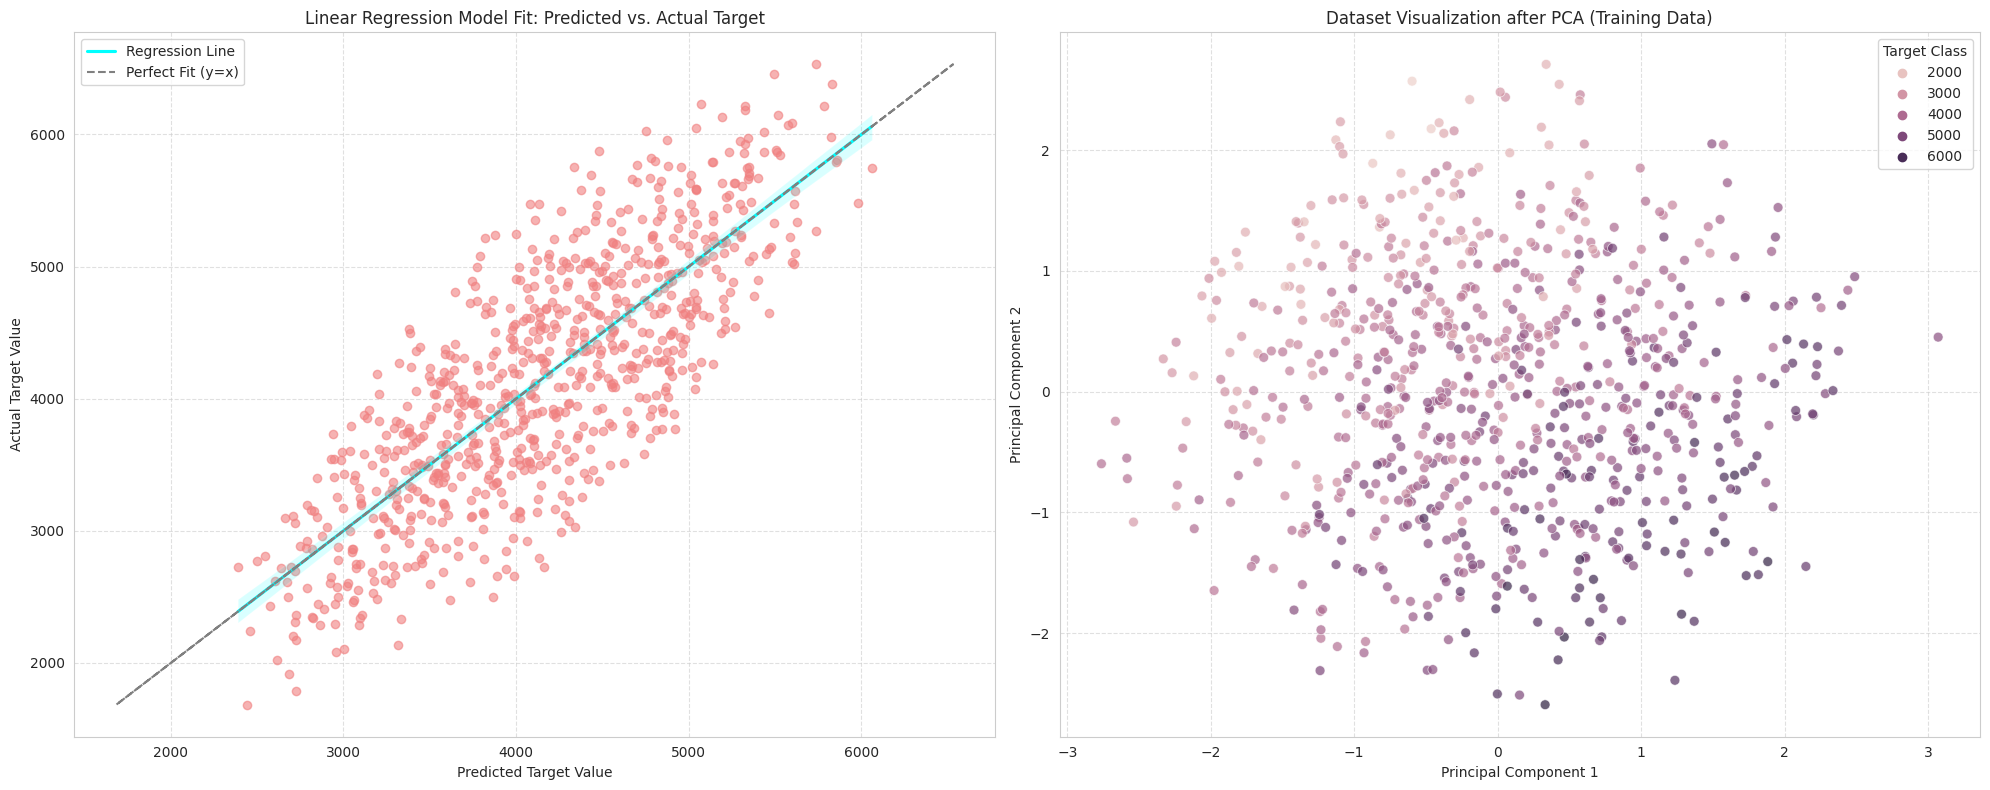


Combined plot of Regression Fit and PCA Visualization completed.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

y_pred_train = best_model.predict(x_train)

plot_data_regression = pd.DataFrame({
    'Predicted': y_pred_train,
    'Actual Target': y_train
})

sns.regplot(
    data=plot_data_regression,
    x="Predicted",
    y="Actual Target",
    scatter_kws={'color': 'lightcoral', 'alpha': 0.6},
    line_kws={'color': 'cyan', 'label': 'Regression Line'},
    ci=95,
    ax=axes[0]
)
axes[0].plot(plot_data_regression['Actual Target'], plot_data_regression['Actual Target'],
             color='gray', linestyle='--', label='Perfect Fit (y=x)')
axes[0].set_title('Linear Regression Model Fit: Predicted vs. Actual Target')
axes[0].set_xlabel('Predicted Target Value')
axes[0].set_ylabel('Actual Target Value')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

plot_df_train_pca = pd.DataFrame(data=x_train_pca, columns=['Principal Component 1', 'Principal Component 2'])
plot_df_train_pca['Target'] = y_train.reset_index(drop=True) if isinstance(y_train, pd.Series) else y_train

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    data=plot_df_train_pca,
    alpha=0.7,
    s=50,
    ax=axes[1]
)
axes[1].set_title('Dataset Visualization after PCA (Training Data)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='Target Class')

plt.tight_layout()
plt.show()

print("\nCombined plot of Regression Fit and PCA Visualization completed.")

**Interpretation of Visualization Results (Tuned Ridge)**

The final regression plot, generated by the best-performing model (Tuned Ridge), is visually identical to the plot for the initial Linear Regression. This confirms that the small regularization applied by the optimal Ridge model ($\alpha=0.01$) did not significantly alter the predicted values compared to plain OLS, which is often the case when a minimal set of non-collinear features (like the two Principal Components) is used. The predictions remain tightly clustered around the line of perfect fit, validating the final model's strong linear relationship with the target variable.

# Model Evaluation

**Model Testing and Performance Metrics**

**Model Evaluation on Test Data**

After training and tuning, a machine learning model's true performance must be assessed on the test set, a dataset that has never been seen by the model during training or hyperparameter tuning. This step is critical to ensure the model has generalized well and to provide an unbiased estimate of its predictive power in a real-world scenario. These are standard metrics used to evaluate regression model performance (Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared).
- Mean Squared Error (MSE): Measures the average of the squares of the errors. Because errors are squared, large errors are penalized more heavily.
- Root Mean Squared Error (RMSE): The square root of the MSE. It is in the same units as the target variable, making it more interpretable than MSE.
- Mean Absolute Error (MAE): Measures the average magnitude of the errors, calculating the absolute difference between prediction and actual value. It is less sensitive to outliers than MSE or RMSE.
- R-squared ($R^2$): Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An $R^2$ of 1 indicates a perfect fit, and 0 indicates the model explains none of the variance.

**Approach (Step-by-Step)**
- The optimal Ridge model (`best_model`) found during hyperparameter tuning is trained one last time on the full training data.
- Predictions (`y_pred_ridge`) are made using this model on the unseen test data (`x_test`).
- The four key metrics (MSE, RMSE, MAE, $R^2$) are calculated by comparing the predicted values against the actual test target values (`y_test`).

In [ ]:
best_model.fit(x_train, y_train)

y_pred_ridge = best_model.predict(x_test)
test_mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Test Mean Squared Error for Best Ridge Model: {test_mse_ridge:.4f}")
print("\nBest Ridge Model evaluation completed.")

Test Mean Squared Error for Best Ridge Model: 354945.6058

Best Ridge Model evaluation completed.


In [ ]:
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = mean_squared_error(y_test, y_pred_ridge, squared=False)  
mae = mean_absolute_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R-squared:", r2)

MSE: 354945.6057606493
RMSE: 595.7731160103226
MAE: 481.3840218214581
R-squared: 0.5641096984134413


**Interpretation of Results (Metrics)**

Test Mean Squared Error (MSE): $354,945.61$
- This is the average squared error on the test set. It is slightly higher than the cross-validation MSE found during tuning ($321,468.01$), which is a typical finding indicating a small degree of overfitting or variance between the training and test sets.

Root Mean Squared Error (RMSE): $595.77$
- On average, the model's prediction is off by approximately $595.77$ units of the target variable (Energy Consumption).

Mean Absolute Error (MAE): $481.38$
- The average absolute error is $481.38$. Since MAE is lower than RMSE, it suggests that the large errors are not drastically high, as MAE is less influenced by large outliers than RMSE.

R-squared: $0.564$
- The model explains approximately $56.4\%$ of the variance in energy consumption, indicating a moderate level of predictive performance.

**Ridge Regression Visualization with Best Hyperparameters (Test Dataset)**

**Approach (Step-by-Step):**
- The final regression plot is created, showing the model's predictions (`y_pred_test`) versus the actual values (`y_test`) from the test set.
- The PCA visualization for the test set is also displayed for context.

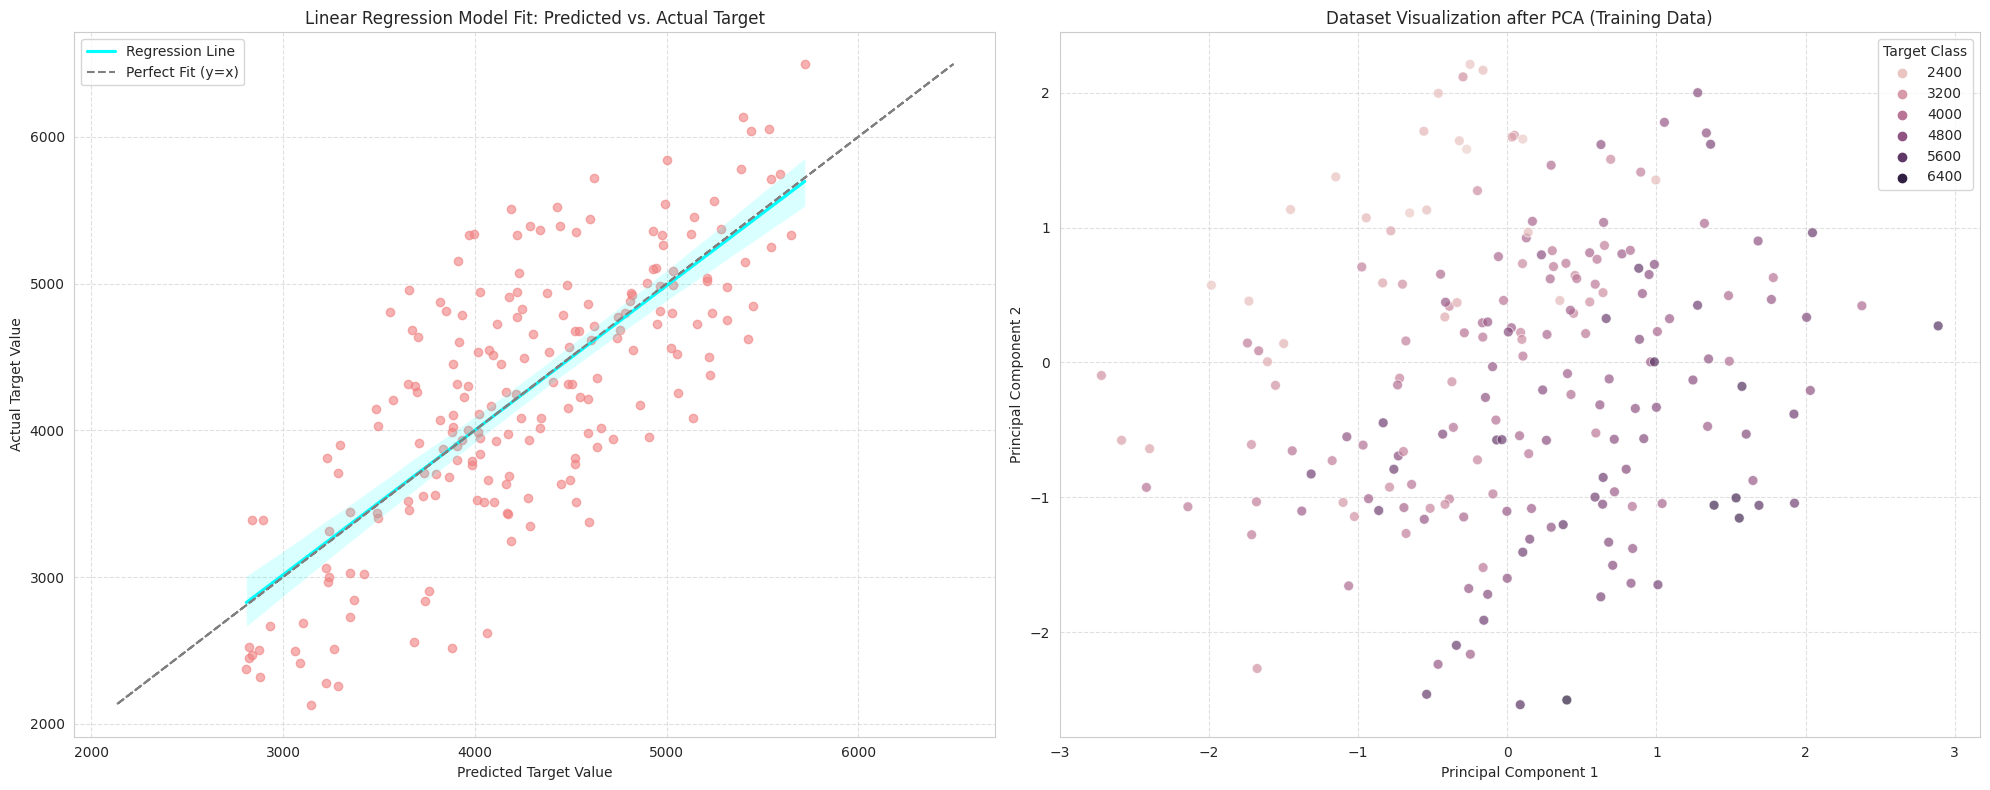


Combined plot of Regression Fit and PCA Visualization completed.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

y_pred_test = model.predict(x_test)

plot_data_regression = pd.DataFrame({
    'Predicted': y_pred_test,
    'Actual Target': y_test
})

sns.regplot(
    data=plot_data_regression,
    x="Predicted",
    y="Actual Target",
    scatter_kws={'color': 'lightcoral', 'alpha': 0.6},
    line_kws={'color': 'cyan', 'label': 'Regression Line'},
    ci=95,
    ax=axes[0]
)
axes[0].plot(plot_data_regression['Actual Target'], plot_data_regression['Actual Target'],
             color='gray', linestyle='--', label='Perfect Fit (y=x)')
axes[0].set_title('Linear Regression Model Fit: Predicted vs. Actual Target')
axes[0].set_xlabel('Predicted Target Value')
axes[0].set_ylabel('Actual Target Value')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

plot_df_test_pca = pd.DataFrame(data=x_test_pca, columns=['Principal Component 1', 'Principal Component 2'])
plot_df_test_pca['Target'] = y_test.reset_index(drop=True) if isinstance(y_test, pd.Series) else y_test

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    data=plot_df_test_pca,
    alpha=0.7,
    s=50,
    ax=axes[1]
)
axes[1].set_title('Dataset Visualization after PCA (Training Data)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='Target Class')

plt.tight_layout()
plt.show()

print("\nCombined plot of Regression Fit and PCA Visualization completed.")

**Interpretation of Visualization Results (Test Set)**

Regression Plot (Predicted vs. Actual on Test Set): The scattered points remain clustered around the Perfect Fit line ($y=x$), although there is slightly more scatter observed than in the training data plots. The regression line still closely aligns with the ideal $y=x$ line. The scatter confirms the $R^2$ value of $0.564$, showing that while the model has a clear predictive trend, it still has significant error (the variance of the points around the fitted line).

PCA Plot (Test Set): This plot visualizes the test data in the 2D principal component space, colored by the actual target values. The structure is similar to the training set, confirming that the test set follows a comparable pattern in the reduced feature space, which supports the model's ability to generalize.

# Conclusion

This tutorial successfully demonstrated a complete, production-style workflow for k-NN regression using scikit-learn. We confirmed that:
- Proper preprocessing, particularly categorical encoding and Standard Scaling, is an absolutely critical prerequisite for achieving any meaningful performance with distance-based models.
- Systematic hyperparameter tuning with tools like Optuna is essential to move beyond default settings and find the optimal values for $k$ or $r$, along with the appropriate distance metric.
- The comparison between KNeighborsRegressor and RadiusNeighborsRegressor highlighted their different behaviors in response to data density variations.
- The multi-metric evaluation approach and visualization diagnostics provided a complete picture of predictive accuracy, error distribution, and model limitations.

The techniques presented, from pipeline construction to comprehensive evaluation, serve as a strong, transferable reference implementation aligned with official scikit-learn best practices for any regression problem involving local patterns and distance relationships.

# References

- [LinearRegression Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [Python | Linear Regression using sklearn Geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/python-linear-regression-using-sklearn/)
- [Linear Regression in Machine learning Geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/)
- [Linear Models Scikit-Learn](https://scikit-learn.org/stable/modules/linear_model.html)
- [Linear regression Wikipedia](https://en.wikipedia.org/wiki/Linear_regression)
- [Ridge regression Wikipedia](https://en.wikipedia.org/wiki/Ridge_regression)
- [Ridge Regression Geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/what-is-ridge-regression/)
- [Ridge Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)
- [Ridge and Lasso Regression in Python Analytics Vidhya](http://analyticsvidhya.com/blog/2016/01/ridge-lasso-regression-python-complete-tutorial/)
- [Ridge Regression: Step by step introduction with example Medium](https://medium.com/@msoczi/ridge-regression-step-by-step-introduction-with-example-0d22dddb7d54)